# Latent segmentation of the held-out images (axis-100-3000)

Pixels of the held-out images are segmented by clustering their latent codes, to see which tissue regions the latent separates, whether the segmentation is reproducible and how molecular classes distribute over the segments (exploded image x m/z view).

## Introduction

A Gaussian mixture with $k$ full-covariance components is fitted on the latent codes of a seeded sample of
training pixels and applied to every held-out pixel. The same procedure on the first ten principal components
of the TIC-normalized inputs gives a reference segmentation: structure that it already finds is linearly
present in the spectra; structure only the latent finds is a contribution of the encoder.

### Assumptions

* `test` pixels come from training images and are spatially correlated with training pixels; `heldout_image`
  pixels come from three images never seen during training. Generalization to new images is therefore judged on
  `heldout_image`, generalization to new pixels on `test`.
* Repetitions differ only in initialization and training seed; they share the split. Five repetitions per axis
  are the experimental units for model-level statements; pixels are not independent units.

        * Mixture labels are arbitrary; every segmentation (other repetitions, input PCA, mixture refits) is aligned to
          the representative model's segmentation of the same $k$ by Hungarian matching, so equal colours denote
          matching segments in every panel. The partition itself is unchanged.
        * Maps, RGB composites, markers and the exploded view show the representative model (next section).
        * Mixture refits: the representative model's codes are fitted again on five independent training subsamples
          (seeds 43-47); their agreement isolates the variability of the mixture fit from that of the model.
        * $k$ for the maps is the value with the lowest mean BIC over repetitions among $k \in \{4, 6, 8, 12\}$; BIC
          favours a mixture fit, not a biologically meaningful number of regions.
        * Classes for the exploded view are selected by two criteria (see `part_1_11`): spatial agreement of the head
          probability with METASPACE, and per-image average precision.

### Notation

* $X \in \mathbb{R}_{\ge 0}^{M}$: TIC-normalized input spectrum on the axis ($M$ bins of 0.55 Da);
  $\hat X = \mathrm{Dec}(\mathrm{Enc}(X))$: its reconstruction (TIC-normalized decoder output).
* $Z = \mathrm{Enc}(X) \in \mathbb{R}^{10}$: latent code; $U$: canonicalized code (bottleneck LayerNorm affine
  removed; rows lie on a sphere of radius $\sqrt{10}$ with zero row sum).
* $\hat Y = \sigma(h(Z)) \in [0, 1]^{C}$: head probabilities of the $C$ train-observed molecule classes.
* $P \in \{\mathrm{train}, \mathrm{test}, \mathrm{test\_extended}, \mathrm{heldout\_image}\}$: pixel population;
  $r = 0, \dots, 4$: repetition (independent training seed of the same configuration).
* $W_1(X, \hat X)$: training Masserstein cost, the exact one-dimensional Wasserstein-1 distance between the
  TIC-normalized spectra, in m/z units.
* Window $W = [a, a + 100)$ m/z, aligned to multiples of 100 on every axis.

        * $s(x) \in \{0, \dots, k-1\}$: segment of pixel $x$; ARI: adjusted Rand index between two partitions.
        * Marker enrichment of bin $j$ in segment $s$: $\log_2(\bar X_{s,j} + \epsilon) - \log_2(\bar X_{\neg s,j} + \epsilon)$.

## Configuration

In [1]:
import logging
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Library modules log INFO to stdout; warnings stay visible, progress messages do not.
logging.disable(logging.INFO)
current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import pretraining_campaign as campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments.pretraining_campaign_precompute import (
    load_metadata, load_table, run_command,
)
from msi_autoencoder_wrapper.analysis.precompute.notebook_inputs import load_model_catalog, load_visualization_theme
from msi_autoencoder_wrapper.visualization import pretraining as figures

SETTINGS_PATH = Path("assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml")
ANALYSIS = "latent_segmentation"
AXIS = "axis-100-3000"

settings = campaign.load_settings(SETTINGS_PATH)
theme = load_visualization_theme(settings).with_overrides(figure_dpi=100)
catalog = load_model_catalog(settings)
metadata = load_metadata(settings, ANALYSIS, AXIS)
pd.set_option("display.precision", 4)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 80)


def table(name: str) -> pd.DataFrame:
    """Load one canonical table written for this notebook by the precompute."""
    return load_table(settings, ANALYSIS, name, AXIS)


def mean_sd(frame: pd.DataFrame, keys: list, columns: list) -> pd.DataFrame:
    """Mean and SD over repetitions of the given columns (presentation helper)."""
    long = frame.melt(id_vars=keys, value_vars=columns, var_name="quantity", value_name="value")
    return long.groupby([*keys, "quantity"]).value.agg(["mean", "std"]).unstack("quantity")


LABELS = list(catalog.drop_duplicates("display_label").sort_values("display_order").display_label)
LABEL_COLORS = {label: figures.model_color(label, theme, position) for position, label in enumerate(LABELS)}
POPULATION_COLORS = {name: figures.population_color(name, theme) for name in figures.POPULATION_ORDER}
CLASS_SET_COLORS = {name: figures.class_set_color(name, theme) for name in figures.CLASS_SET_ORDER}
print("Analysis:", ANALYSIS, "| axis:", AXIS, "| models:", len(metadata["models"]))
print("Cache keys:", metadata["cache_keys"])

POPULATIONS = ['train', 'test', 'test_extended', 'heldout_image']
AXIS_LABEL = settings['axes'][AXIS]['label']
MODEL_LABEL = catalog[catalog.axis == AXIS].display_label.iloc[0]
DATASETS = sorted(load_table(settings, 'heldout_image_reconstruction', 'image_metrics', AXIS).dataset_id.unique())
print('Axis label:', AXIS_LABEL, '| held-out images:', DATASETS)

SELECTED_K = metadata['selected_k']
REFERENCE = int(metadata['reference_repetition'])
labels = table('labels')
print('Selected k:', SELECTED_K, '| representative model:', metadata['representative_model'], '(repetition', REFERENCE, ')')

Analysis: latent_segmentation | axis: axis-100-3000 | models: 5
Cache keys: {'plan': 'f34a92a8f6f7833f', 'populations': '513690bdd78a83ce', 'inference': '0243c1efb93b9c4c'}
Axis label: 100-3000 m/z | held-out images: ['2024-02-20_01h45m20s', '2024-02-20_01h46m58s', '2024-02-20_01h54m41s']


Selected k: 12 | representative model: metaspace-pretrain-repaired-20260923-01__grid_0011__rep_01__real_only (repetition 1 )


## Producing the tables this notebook reads

### Methodology

#### Implementation

`latent_segmentation` fits the mixtures on stored latent codes (and on input PCA of the stored inputs),
predicts held-out segments, refits the representative model's mixture on independent subsamples, aligns
labels, computes RGB composites, marker bins, stability, segment overlaps, composition and the class-segment
overlap. No model is evaluated.

The command below is generated by the precompute entry point itself; if a table is missing, `load_table` raises with the same command.

In [2]:
print(run_command(settings, ANALYSIS))

nohup uv run --extra cu118 python -m msi_autoencoder_wrapper.analysis.precompute --settings /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml --analysis latent_segmentation > /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/shared_precompute.log 2>&1 &


### Remarks

### Notes

## Representative model shown in the images

### Methodology

#### Theoretical

Images are never averaged over repetitions, because averaging blurs them. Every image shows the
representative model of its axis: the repetition with the lowest mean rank over five metrics on the withheld
test pixels, Masserstein $W_1$ and spectral angle (lower is better), macro AP, micro AP and macro F1 at 0.5
(higher is better; annotation retrieval, classes observed in training); equal mean ranks are decided by macro
AP. The held-out images are not used for the choice, so the displayed model is not selected on the images it
is shown on.

#### Implementation

`representative_model` holds, per model and metric, the test value, its rank among the repetitions of the axis, the mean rank and the flag.

#### Figure descriptions

No figure; one row per model with the metric values, the mean rank and the representative flag.

In [3]:
ranking = table('representative_model')
values = ranking.pivot_table(index=['axis', 'repetition', 'model_id'], columns='metric', values='value')
flags = ranking.groupby(['axis', 'repetition', 'model_id']).agg(mean_rank=('mean_rank', 'first'), representative=('representative', 'first'))
display(values.join(flags).round(4))

average_precision      f1  masserstein  micro_average_precision  spectral_angle  mean_rank  representative
axis          repetition model_id                                                                                                                                                      
axis-100-3000 0          metaspace-pretrain-repaired-20260923-01__grid_0...             0.7052  0.5102       4.0381                   0.8771          1.0991        3.2           False
              1          metaspace-pretrain-repaired-20260923-01__grid_0...             0.6942  0.5129       4.0117                   0.8824          1.0917        2.0            True
              2          metaspace-pretrain-repaired-20260923-01__grid_0...             0.6851  0.4777       3.7285                   0.8647          1.0539        3.4           False
              3          metaspace-pretrain-repaired-20260923-01__grid_0...             0.7068  0.5122       4.0129                   0.8813          1.1247        2.8           False
              4          metaspace-pretrain-repaired-20260923-01__grid_0...             0.6951  0.5102       4.1471                   0.8816          1.1029        3.6           False

### Remarks

- Representative model: repetition 1 (mean rank 2.0 of 5; the others 2.8-3.6). Repetitions differ little (macro AP 0.685-0.707, $W_1$ 3.73-4.15), so the choice is weakly determined; images of another repetition would differ in detail, not in pattern (see the SD maps of `part_1_04`).

### Notes

## Choice of the number of segments

### Methodology

#### Theoretical

The Bayesian information criterion of the mixture on the fitting sample trades likelihood against the number
of parameters; the minimum is the preferred $k$.

#### Implementation

`bic` holds one value per representation, repetition and $k$ (input PCA has repetition -1).

#### Figure descriptions

x = $k$, y = BIC (lower is better); colour = representation, one line per repetition.

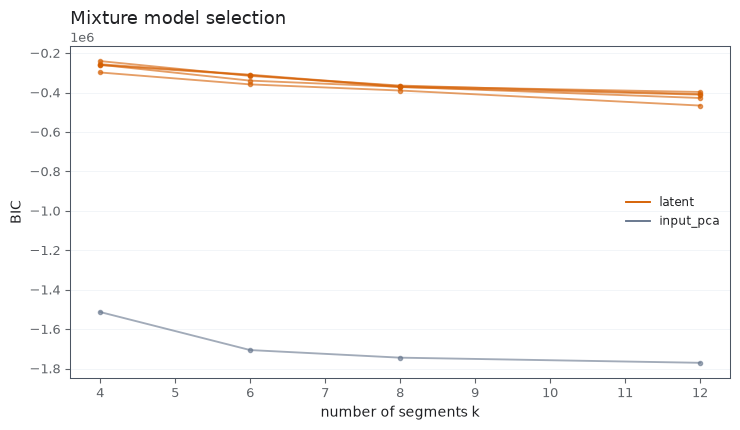

In [4]:
bic = table('bic')
figures.line_by_repetition(bic, x='k', y='bic', color_by='representation', levels=['latent', 'input_pca'], colors={'latent': LABEL_COLORS[MODEL_LABEL], 'input_pca': theme.input_color}, xlabel='number of segments k', ylabel='BIC', title='Mixture model selection', theme=theme);

### Remarks

- BIC decreases up to $k$ = 12 for latent and input PCA; not informative about the number of regions.

### Notes

## Segment maps of the held-out images

### Methodology

#### Theoretical

Segment maps of the representative model, of the other repetitions and of the input-PCA reference at the
selected $k$ show which regions the latent separates and whether repetitions agree spatially. All maps are
aligned to the representative model, so one colour is one matched segment across the panels.

#### Implementation

`labels` holds aligned segments per held-out pixel, representation, repetition and $k$.

#### Figure descriptions

Rows = held-out images; columns = representative model (first), the other repetitions, input PCA; colour = aligned segment index (same palette in every panel).

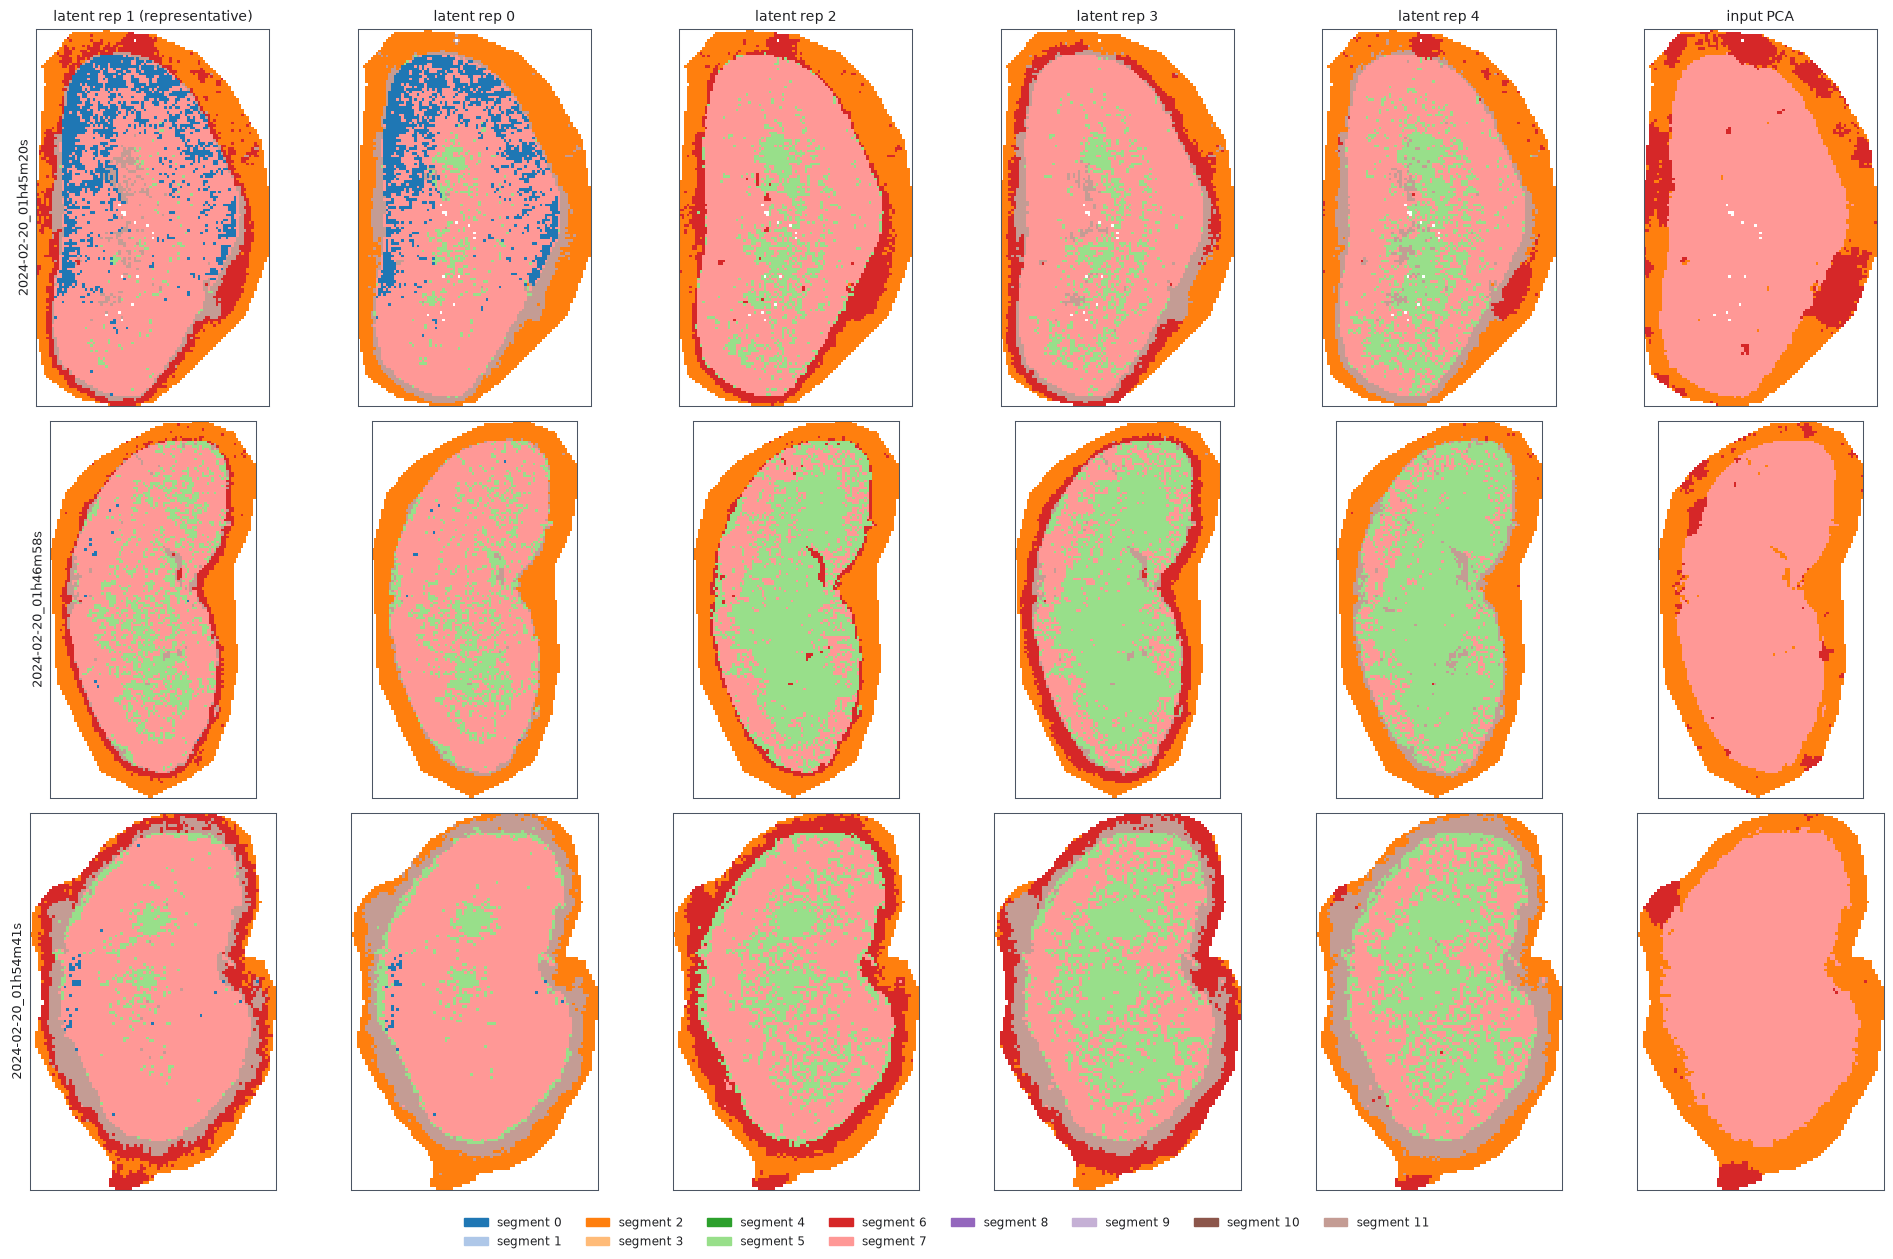

In [5]:
chosen = labels[labels.k == SELECTED_K].copy()
chosen['labelling'] = np.where(chosen.representation == 'latent', 'latent rep ' + chosen.repetition.astype(str), 'input PCA')
chosen.loc[(chosen.representation == 'latent') & (chosen.repetition == REFERENCE), 'labelling'] = f'latent rep {REFERENCE} (representative)'
wide = chosen.pivot_table(index=['row', 'dataset_id', 'x', 'y'], columns='labelling', values='segment').reset_index()
columns = [f'latent rep {REFERENCE} (representative)'] + sorted(column for column in wide.columns if str(column).startswith('latent rep') and 'representative' not in str(column)) + ['input PCA']
figures.label_panels(wide, label_columns=columns, column_titles=columns, datasets=DATASETS, k=SELECTED_K, theme=theme);

### Remarks

- Aligned colours show the same coarse regions in every repetition; at $k$ = 12 six segments occur on the held-out pixels.

### Notes

## RGB composites of the latent codes

### Methodology

#### Theoretical

The first three principal components of the representative model's held-out codes mapped to red, green and
blue show the continuous latent structure without choosing $k$.

#### Implementation

`rgb` holds per pixel the representative model's PCA components scaled to [0, 1] (1st-99th percentile).

#### Figure descriptions

Rows = held-out images; one column (representative model).

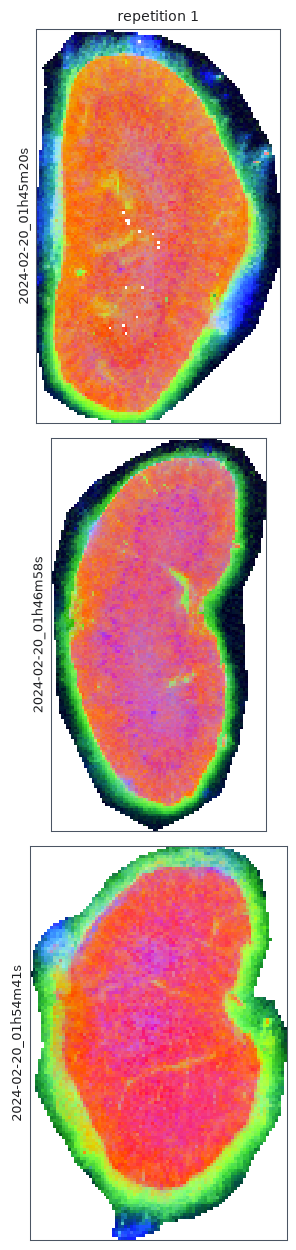

In [6]:
figures.rgb_panels(table('rgb'), repetitions=[REFERENCE], datasets=DATASETS, theme=theme);

### Remarks

### Notes

## Reproducibility of the segmentation

### Methodology

#### Theoretical

Three agreements per $k$, all as adjusted Rand index (ARI): between the segmentations of two repetitions
(reproducibility of the model), between the representative model's mixture and its refits on independent
training subsamples (reproducibility of the mixture fit alone) and between a latent and the input-PCA
segmentation (difference from linear spectral structure). If refits agree much better than repetitions, the
disagreement comes from the models, not from the clustering.

#### Implementation

`stability` holds the ARI per $k$ and pair.

#### Figure descriptions

x = $k$, y = ARI; colour = comparison, one point per pair, bar = mean. The table gives means per $k$.

comparison,latent_repetitions,mixture_refits,latent_vs_input_pca
k,,,
4,0.930,0.982,0.874
6,0.961,0.976,0.916
8,0.910,0.866,0.871
12,0.569,0.454,0.488


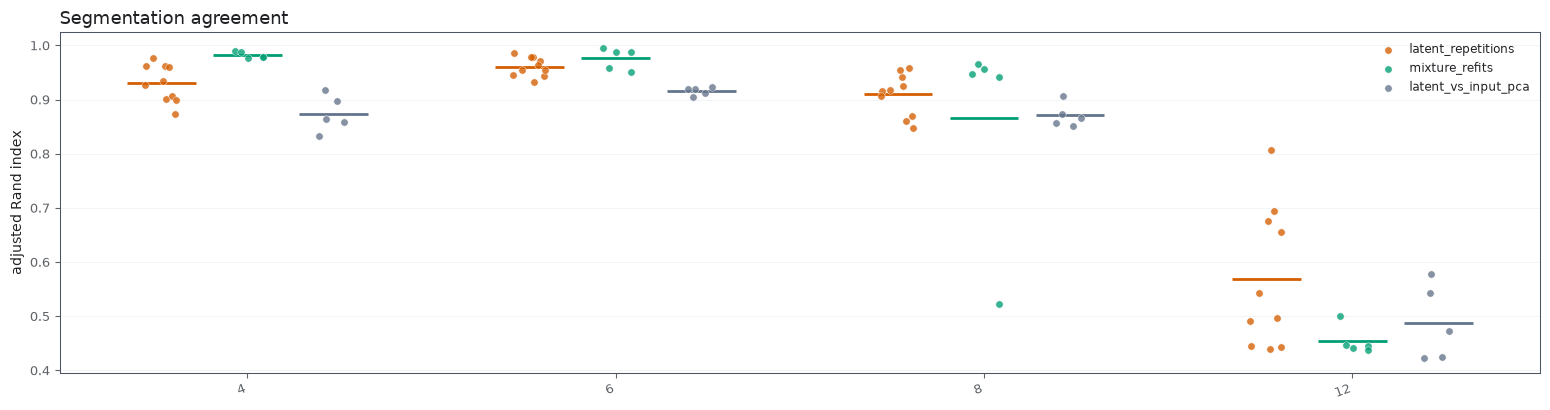

In [7]:
stability = table('stability')
stability['k'] = stability.k.astype(str)
comparisons = ['latent_repetitions', 'mixture_refits', 'latent_vs_input_pca']
figures.repetition_points(stability, value='ari', group='k', hue='comparison', order=sorted(stability.k.unique(), key=int), hue_order=comparisons, colors={'latent_repetitions': LABEL_COLORS[MODEL_LABEL], 'mixture_refits': theme.model_palette[2], 'latent_vs_input_pca': theme.input_color}, ylabel='adjusted Rand index', title='Segmentation agreement', theme=theme);
display(stability.pivot_table(index='k', columns='comparison', values='ari', aggfunc='mean')[comparisons].loc[sorted(stability.k.unique(), key=int)].round(3))

### Remarks

- ARI between repetitions 0.93 / 0.96 / 0.91 / 0.57 at $k$ = 4 / 6 / 8 / 12; between mixture refits 0.98 / 0.98 / 0.87 / 0.45; latent against input PCA 0.87 / 0.92 / 0.87 / 0.49.
- Unlike the narrow axis, at $k$ = 12 the refits of one model agree less than the repetitions: here the mixture fit itself is not reproducible at fine resolution.

### Notes

## Which segments correspond: overlap matrices

### Methodology

#### Theoretical

The ARI summarises agreement in one number; the overlap matrix shows which segments match, split or merge.
Entry $(a, b)$ is the share of the representative model's segment $a$ that falls into segment $b$ of the compared
partition. After alignment the diagonal holds the matched share; off-diagonal mass shows a segment split between
two segments of the other partition.

#### Implementation

`contingency` (representative partition against every other partition) at the selected $k$; shares are averaged over the compared repetitions and over the refits.

#### Figure descriptions

Three heat maps: rows = segment of the representative model, columns = segment of the compared partition, colour = share of the row segment (rows sum to 1).

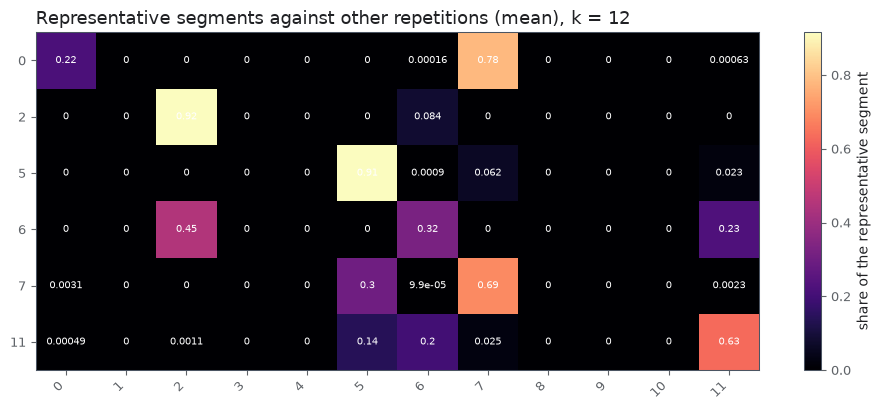

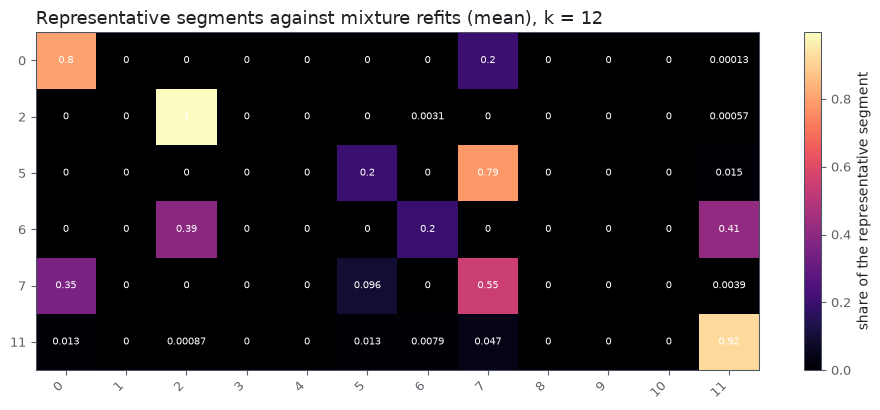

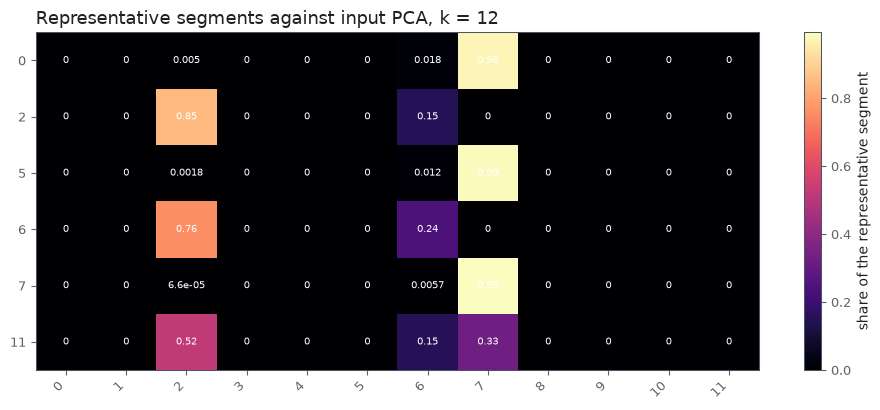

In [8]:
contingency = table('contingency')
shown = contingency[contingency.k == SELECTED_K]
for comparison, title in (('latent_repetition', 'other repetitions (mean)'), ('mixture_refit', 'mixture refits (mean)'), ('input_pca', 'input PCA')):
    matrix = shown[shown.comparison == comparison].pivot_table(index='reference_segment', columns='other_segment', values='reference_fraction', aggfunc='mean')
    figures.matrix_heatmap(matrix, title=f'Representative segments against {title}, k = {SELECTED_K}', colorbar_label='share of the representative segment', annotate=True, theme=theme)
    plt.show()

### Remarks

- Matched pixel share at $k$ = 6: 0.99 (repetitions), 0.99 (refits), 0.98 (input PCA); at $k$ = 12: 0.68, 0.60, 0.69.
- At $k$ = 12 segment 6 of the representative model is matched for only 20-32 % of its pixels: it is split between neighbouring segments in every comparison.

### Notes

## Segment composition and marker m/z

### Methodology

#### Theoretical

The fraction of every image covered by each segment and the most enriched bins of each segment characterise
what a segment is spectrally.

#### Implementation

`composition` and `markers` for the representative model at the selected $k$ (latent representation).

#### Figure descriptions

No figure; tables of segment fractions per image and the top five marker m/z per segment.

In [9]:
composition = table('composition')
reference = int(metadata['reference_repetition'])
display(composition[(composition.representation == 'latent') & (composition.repetition == reference) & (composition.k == SELECTED_K)].pivot_table(index='segment', columns='dataset_id', values='fraction').round(3))
markers = table('markers')
display(markers[(markers.representation == 'latent') & (markers.repetition == reference) & (markers.k == SELECTED_K) & (markers['rank'] < 5)][['segment', 'rank', 'mz', 'log2_enrichment', 'segment_fraction']])

dataset_id,2024-02-20_01h45m20s,2024-02-20_01h46m58s,2024-02-20_01h54m41s
segment,,,
0,0.141,0.001,0.005
2,0.192,0.252,0.078
5,0.011,0.166,0.054
6,0.108,0.069,0.148
7,0.484,0.484,0.590
11,0.064,0.027,0.126


,segment,rank,mz,log2_enrichment,segment_fraction
70,0,0,750.9286,3.1725,0.0544
71,0,1,755.8787,3.0593,0.0544
72,0,2,732.2285,2.9496,0.0544
73,0,3,726.7285,2.6024,0.0544
74,0,4,754.7787,2.4863,0.0544
80,2,0,470.4271,5.5415,0.1787
81,2,1,158.5753,5.3559,0.1787
82,2,2,392.8766,5.3002,0.1787
83,2,3,202.0256,5.2548,0.1787
84,2,4,334.0263,5.1706,0.1787


### Remarks

### Notes

## Molecular classes over the segments (exploded image x m/z view)

### Methodology

#### Theoretical

For each selected class the fraction of METASPACE-positive pixels in every segment shows whether a molecule
is confined to a latent region. The exploded view stacks the segment map (bottom) and the ion layers of the
selected classes above it in the order of their m/z (equal spacing), so overlaps between segments and molecules
are visible in one figure.

#### Implementation

`class_overlap` and `exploded_layers` hold, for the classes selected by each criterion (best and worst three),
METASPACE intensity, input ion intensity, head probability and segment of the representative model per pixel.
Every ion layer is scaled to its own 99th percentile.

#### Figure descriptions

Table: per selected class and segment the METASPACE-positive fraction. Figures: one exploded view per
criterion for the image holding most selected classes, once with METASPACE intensities and once with head
probabilities as layer colour; bottom plane = latent segments at the selected $k$; upper planes = classes in m/z
order (z tick labels give class and m/z).

segment                                                          0     2     5     6     7     11
criterion          kind  class_name      dataset_id                                              
average_precision  best  C12H8O4|-H      2024-02-20_01h54m41s  1.00  0.30  1.00  0.80  1.00  0.99
                         C47H79O12P|-H   2024-02-20_01h46m58s  0.93  0.00  0.90  0.16  0.97  0.71
                         C49H86O13P2|-H  2024-02-20_01h46m58s  1.00  0.00  1.00  0.22  1.00  0.76
                   worst C12H21N7O3|[M]- 2024-02-20_01h46m58s  0.00  0.02  0.01  0.09  0.00  0.08
                         C39H78NO8P|-H   2024-02-20_01h54m41s  0.00  0.00  0.12  0.05  0.02  0.18
                         C41H73O8P|-H    2024-02-20_01h54m41s  0.00  0.00  0.01  0.01  0.00  0.04
metaspace_spearman best  C19H34O12|-H    2024-02-20_01h46m58s  0.00  0.84  0.00  0.07  0.00  0.02
                         C47H79O12P|-H   2024-02-20_01h45m20s  0.92  0.00  0.72  0.05  0.82  0.54
                         C49H86O13P2|-H  2024-02-20_01h46m58s  1.00  0.00  1.00  0.22  1.00  0.76
                   worst C39H78NO8P|-H   2024-02-20_01h54m41s  0.00  0.00  0.12  0.05  0.02  0.18
                         C40H73N2O7P|-H  2024-02-20_01h54m41s  0.23  0.84  0.29  0.68  0.69  0.57
                         C41H73O8P|-H    2024-02-20_01h54m41s  0.00  0.00  0.01  0.01  0.00  0.04

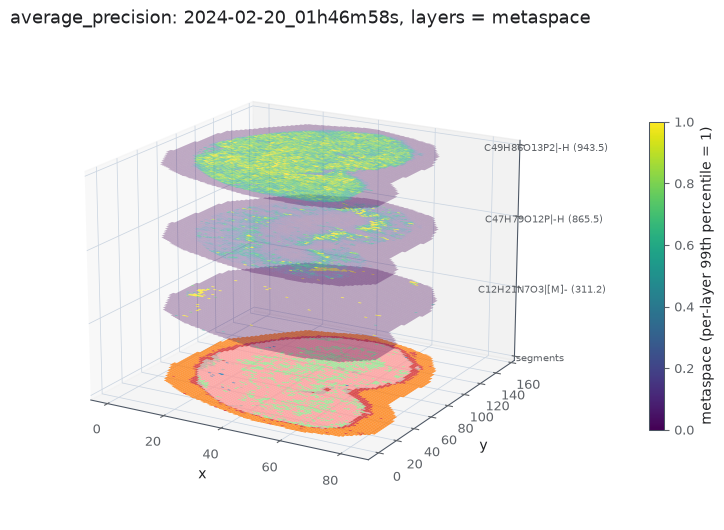

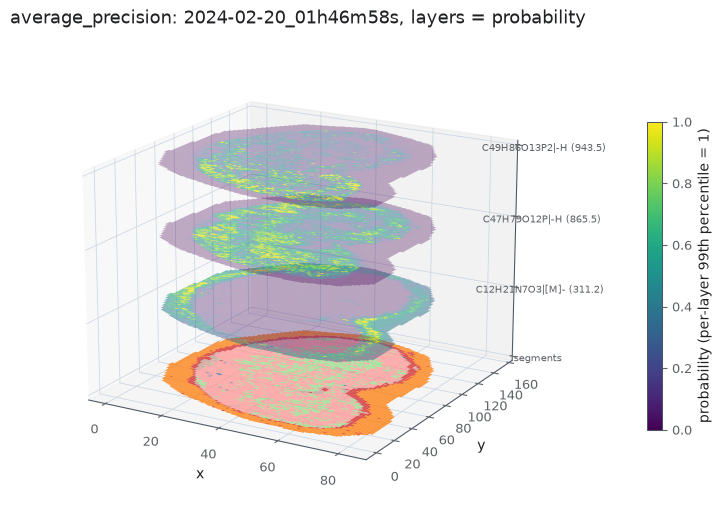

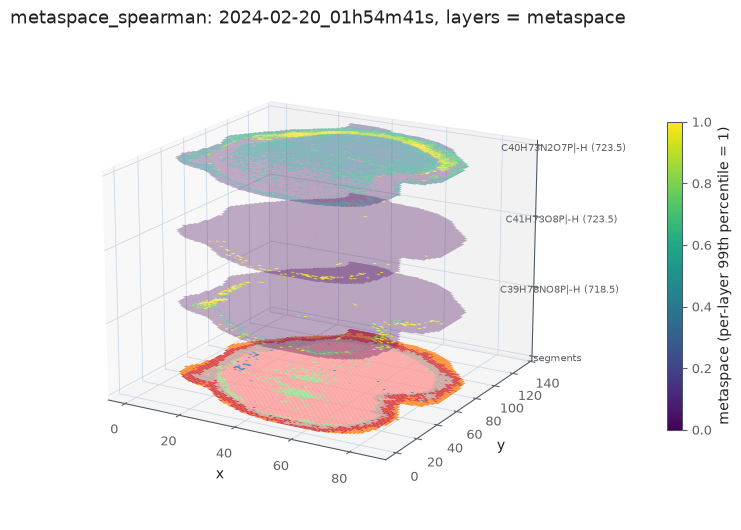

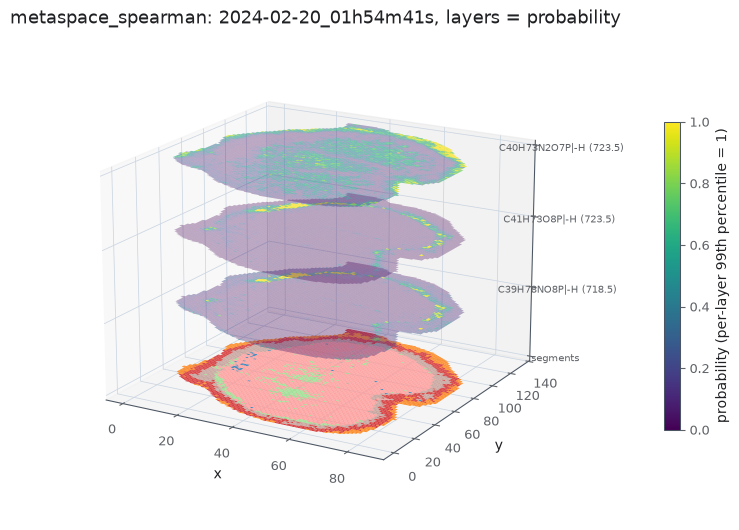

In [10]:
overlap = table('class_overlap')
display(overlap.pivot_table(index=['criterion', 'kind', 'class_name', 'dataset_id'], columns='segment', values='metaspace_positive_fraction').round(2))
layers = table('exploded_layers')
for criterion, frame in layers.groupby('criterion'):
    dataset = frame.drop_duplicates('class_name').dataset_id.value_counts().index[0]
    classes = list(frame[frame.dataset_id == dataset].class_name.unique())
    for value in ('metaspace', 'probability'):
        figures.exploded_view(frame, dataset=dataset, classes=classes, value=value, k=SELECTED_K, title=f'{criterion}: {dataset}, layers = {value}', theme=theme)
        plt.show()

### Remarks

- The extension class C49H86O13P2|-H (943.5), best by both criteria, is METASPACE-positive in every pixel of segments 5 and 7 and in none of segment 2 (image 01h46m58s): the latent segmentation separates where this molecule occurs.

### Notes

## Results / Summary

### LLM

- **Observed:** reproducible segmentation at $k$ = 4-6 (ARI 0.93-0.98), unreproducible at $k$ = 12, where even refits of one mixture disagree (ARI 0.45).
- **Interpretation:** the wide-axis latent supports the same five to six regions as the narrow one (see the cross-axis agreement in `part_1_13`); $k$ = 6 is the resolution to use for comparisons.

### Person